In [4]:
# 导入必要的Python库
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier  # 用于ID3决策树 (近似)
from sklearn import tree  # C5.0近似使用DecisionTree (sklearn无精确C5.0)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
import re  # 字符串处理 (str.replace_all类似)
import catboost as cb
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, train_test_split
from catboost import CatBoostClassifier

ImportError: cannot import name 'get_tags' from 'sklearn.utils._tags' (c:\Users\zhang\anaconda3\Lib\site-packages\sklearn\utils\_tags.py)

In [ ]:
# 1. 读取训练和测试数据
data_train = pd.read_csv("E:/Code/python/pre-payback/train.csv")
data_test = pd.read_csv("E:/Code/python/pre-payback/test.csv")

In [ ]:
# 2. 预处理: 修改grade_subgrade的映射 (A=1, B=2, 等)
grade_map = {'A': '1', 'B': '2', 'C': '3', 'D': '4', 'E': '5', 'F': '6', 'G': '7'}
data_train['grade_subgrade'] = data_train['grade_subgrade'].astype(str).replace(grade_map, regex=True)
data_test['grade_subgrade'] = data_test['grade_subgrade'].astype(str).replace(grade_map, regex=True)

In [6]:
#  将非数值型变量转换为数值型 (排除grade_subgrade)

data_train_origin = data_train.copy() #保留一份未转化的数据,方便后面catboost模型训练
data_test_origin  = data_test.copy()

def convert_to_numeric(df):
    exclude_col = 'grade_subgrade'
    for col in df.columns:
        if col != exclude_col and (df[col].dtype == 'object' or df[col].dtype.name == 'category'):
            df[col] = pd.Categorical(df[col]).codes.astype(float)
    return df

data_train = convert_to_numeric(data_train)
data_test = convert_to_numeric(data_test)
# 强制转换grade_subgrade为数值
data_train['grade_subgrade'] = pd.to_numeric(data_train['grade_subgrade'])
data_test['grade_subgrade'] = pd.to_numeric(data_test['grade_subgrade'])


In [11]:
# 4. 存储测试ID并删除ID列
test_ids = data_test['id']
data_train = data_train.drop('id', axis=1)
data_test = data_test.drop('id', axis=1)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.490825,1.472616,0.831498,0.685438,2.609976,36.947599,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.512317,0.585860,0.972475,1.332355,1.656488,9.944468,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,0.000000,1.000000,0.000000,0.000000,2.000000,32.000000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,0.000000,1.000000,1.000000,0.000000,2.000000,34.000000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000,2.000000,1.000000,0.000000,3.000000,43.000000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,2.000000,3.000000,4.000000,4.000000,7.000000,65.000000,1.000000


In [24]:
# 5. 划分数据集， 8：2

X = data_train.drop('loan_paid_back', axis=1)
y = data_train['loan_paid_back']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=123)

#未转化后的数据划分
y_origin= data_train_origin['loan_paid_back']
X_origin= data_train_origin.drop('loan_paid_back', axis=1)
X_train_origin, X_valid_origin, y_train_origin, y_valid_origin = train_test_split(X_origin, y_origin, train_size=0.8,test_size=0.2, random_state=123)

#五折交叉验证
N_SPLITS = 5
RANDOM_STATE = 123

skf = StratifiedKFold(
    n_splits=N_SPLITS, 
    shuffle=True, 
    random_state=RANDOM_STATE
)

In [10]:
#roc曲线定义
def plot_roc_curve(y_true, y_probas, model_name="模型"):

    # 1. 计算 ROC 曲线的 FPR 和 TPR

    fpr, tpr, thresholds = roc_curve(y_true, y_probas)

    # 2. 计算 AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)

    # 3. 绘制 ROC 曲线
    plt.figure()
    
    # 绘制模型的 ROC 曲线
    plt.plot(fpr, tpr, 
             label=f'{model_name} (AUC = {roc_auc:.4f})',
             color='darkorange', linewidth=2)
    
    # 绘制对角线 (随机分类器)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='(AUC = 0.50)')
    
    # 设置图表属性
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR') # 假正率
    plt.ylabel('TPR')  # 真正率
    plt.title(f'{model_name}  (ROC) ')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
def auc_acc (y_true, y_probas, model_name="model"):
    y_valid = (np.array(y_probas)>=0.5).astype(int)   #转化为二分类
    acc = accuracy_score(y_true, y_valid) #二分类计算
    auc = roc_auc_score(y_true, y_probas) #与预测概率计算
    print(f"{model_name}")
    print(f"auc: {auc:.4f}") # 4f后面不能带空格
    print(f"acc: {acc:.4f}")


----- 训练ID3模型 ----- 


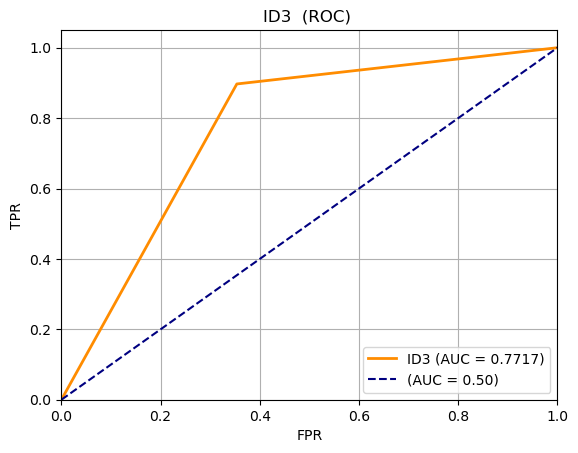

ID3
auc: 0.7717
acc: 0.8464


In [14]:
# 6.1. ID3决策树 (使用DecisionTreeClassifier, Gini不纯度)
print("\n----- 训练ID3模型 ----- ")
id3_model = DecisionTreeClassifier(random_state=123)
id3_model.fit(X_train, y_train)
# 预测概率和标签
id3_proba_valid = id3_model.predict_proba(X_valid)[:, 1] # 使用 X_valid
id3_pred = id3_model.predict(X_valid)



plot_roc_curve(y_valid, id3_proba_valid, model_name="ID3")

auc_acc (y_valid, id3_proba_valid, model_name="ID3")



In [ ]:
# 6.2. C5.0模型 (近似使用DecisionTree with entropy)
print("\n----- 2. 训练C5.0 (DecisionTree entropy)模型 ----- ")
c50_model = DecisionTreeClassifier(criterion='entropy', random_state=123)
c50_model.fit(X_train, y_train)
c50_proba_valid = c50_model.predict_proba(X_valid)[:, 1]
c50_pred = c50_model.predict(X_valid)
# 计算准确率和AUC
c50_acc = accuracy_score(y_valid, c50_pred)
c50_auc = roc_auc_score(y_valid, c50_proba_valid)
print(f"C5.0模型验证集 AUC: {c50_auc:.4f}")
print(f"C5.0模型验证集准确率: {c50_acc:.4f}")

In [ ]:
'''#高斯核的问题
问题出现 高斯核的计算量非常大
# 6.3. SVM模型 (径向基核)
print("\n----- 3. 训练SVM模型 ----- ")
svm_model = SVC(kernel='rbf', probability=True, random_state=123)
svm_model.fit(X_train, y_train)
svm_proba_valid = svm_model.predict_proba(X_valid)[:, 1]
svm_pred = svm_model.predict(X_valid)
# 计算准确率和AUC
svm_acc = accuracy_score(y_valid, svm_pred)
svm_auc = roc_auc_score(y_valid, svm_proba_valid)
print(f"SVM模型验证集 AUC: {svm_auc:.4f}")
print(f"SVM模型验证集准确率: {svm_acc:.4f}")
'''


----- 训练LightGBM模型 ----- 
[LightGBM] [Info] Number of positive: 379665, number of negative: 95530
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1586
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798967 -> initscore=1.379849
[LightGBM] [Info] Start training from score 1.379849


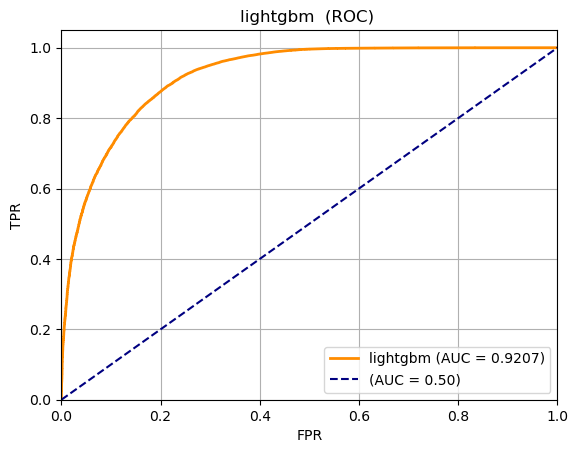

lightgbm
auc: 0.9207
acc: 0.9051


In [17]:
#LightGBM
print("\n----- 训练LightGBM模型 ----- ")
lgbm_model = LGBMClassifier(random_state=123, n_jobs=-1) 
lgbm_model.fit(X_train, y_train)

# 预测
lgbm_proba_valid = lgbm_model.predict_proba(X_valid)[:, 1]
lgbm_pred = lgbm_model.predict(X_valid)

plot_roc_curve(y_valid,lgbm_proba_valid,model_name= 'lightgbm')
auc_acc(y_valid,lgbm_proba_valid,model_name= 'lightgbm')


C:\Users\zhang\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


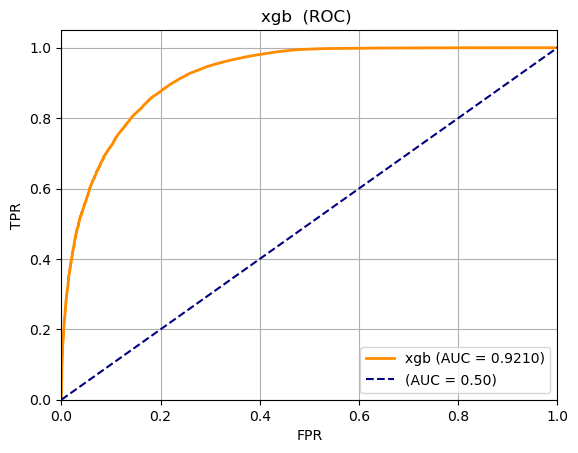

xgb
auc: 0.9210
acc: 0.9041


In [18]:
#xgboost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # 二分类问题
    use_label_encoder=False,      # 避免版本警告
    eval_metric='logloss',        # 评估指标
    n_jobs=-1,                    # 使用所有核心加速
    random_state=123
)
xgb_model.fit(X_train, y_train)

# 预测概率和标签
xgb_proba_valid = xgb_model.predict_proba(X_valid)[:, 1]  # 正类概率
xgb_pred = xgb_model.predict(X_valid)

plot_roc_curve(y_valid,xgb_proba_valid,model_name="xgb")
auc_acc(y_valid,xgb_proba_valid,model_name="xgb")

CatBoost 模型验证集 AUC: 0.9229
CatBoost 模型验证集准确率: 0.9063

----- 训练 CatBoost 模型并记录性能指标 ----- 

----- 绘制 ROC 曲线 ----- 


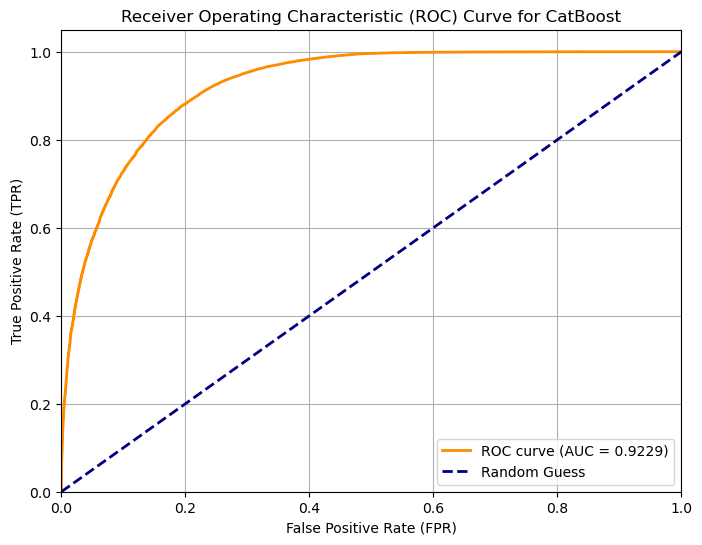


----- 绘制 AUC 迭代历史曲线 ----- 


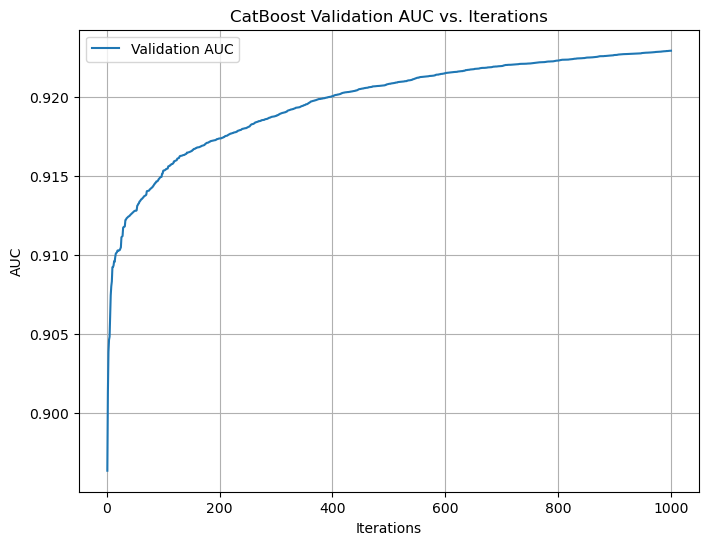

In [17]:
#catmodel
cat_model = cb.CatBoostClassifier(
    iterations=1000,                  # 迭代次数 (可调)
    learning_rate=0.05,              # 学习率 (可调)
    loss_function='Logloss',         # 二分类损失函数
    eval_metric='AUC',
    verbose=False,                   # 关闭训练过程打印信息
    random_seed=123
)
# 训练模型
cat_model.fit(X_train_origin, y_train_origin, eval_set=(X_valid_origin, y_valid_origin))

# 预测概率和标签
cat_proba_valid = cat_model.predict_proba(X_valid_origin)[:, 1]
cat_pred = cat_model.predict(X_valid_origin)

# 计算准确率和AUC

plot_roc_curve(y_valid,cat_proba_valid,model_name="cat")
auc_acc(y_valid,cat_proba_valid,model_name="cat")




----- 开始 5 折 CatBoost 分层交叉验证 -----

--- 正在处理第 1 折 (Fold 1/5) ---
   第 1 折 CatBoost AUC: 0.9224

--- 正在处理第 2 折 (Fold 2/5) ---
   第 2 折 CatBoost AUC: 0.9187

--- 正在处理第 3 折 (Fold 3/5) ---
   第 3 折 CatBoost AUC: 0.9204

--- 正在处理第 4 折 (Fold 4/5) ---
   第 4 折 CatBoost AUC: 0.9211

--- 正在处理第 5 折 (Fold 5/5) ---
   第 5 折 CatBoost AUC: 0.9246

----- 交叉验证结果汇总 -----
所有 5 折的 AUC 分数: [np.float64(0.9223503768221144), np.float64(0.9186511883301078), np.float64(0.9203896157204967), np.float64(0.9210752074182722), np.float64(0.9245575597529908)]
CatBoost 平均 AUC: 0.9214 ± 0.0020

----- 最终模型训练与评估 (使用 80% 训练集, 20% 验证集) -----

[最终模型在 20% 验证集上的表现]
CatBoost Final
auc: 0.9231
acc: 0.9063


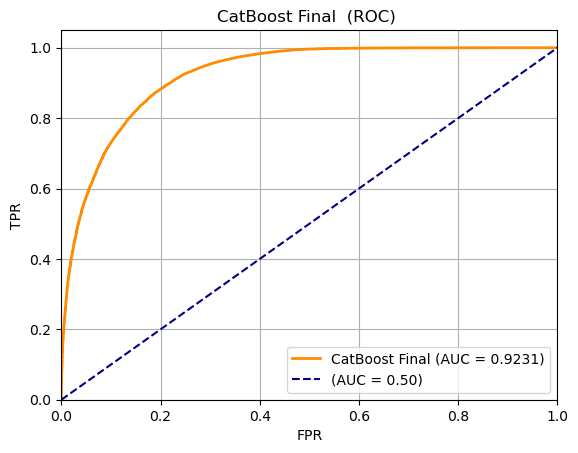

In [27]:
#catboost五折交叉验证：
CAT_FEATURES = [] 
# ----------------------------------------------------

cv_auc_scores = []
final_model = None # 用于存储最终模型

print(f"\n----- 开始 {N_SPLITS} 折 CatBoost 分层交叉验证 -----")

# 使用 X 和 y (完整数据集) 进行交叉验证
for fold, (train_index, valid_index) in enumerate(skf.split(X, y), 1):
    
    print(f"\n--- 正在处理第 {fold} 折 (Fold {fold}/{N_SPLITS}) ---")
    
    # 1. 调用/切分当前折叠的数据集
    FOLD_TRAIN_X = X.iloc[train_index]
    FOLD_VALID_X = X.iloc[valid_index]
    FOLD_TRAIN_Y = y.iloc[train_index]
    FOLD_VALID_Y = y.iloc[valid_index]

    # 2. 引用和初始化 CatBoost 模型
    cb_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE + fold,
        verbose=0,
        allow_writing_files=False
    )
    
    # 3. 训练模型，并指定分类特征
    cb_model.fit(
        FOLD_TRAIN_X, FOLD_TRAIN_Y,
        cat_features=CAT_FEATURES,
        eval_set=(FOLD_VALID_X, FOLD_VALID_Y),
        early_stopping_rounds=50,
        verbose=False
    )
    
    # 4. 调用模型进行预测和评估
    y_valid_proba = cb_model.predict_proba(FOLD_VALID_X)[:, 1]
    
    fold_auc = roc_auc_score(FOLD_VALID_Y, y_valid_proba)
    cv_auc_scores.append(fold_auc)
    
    print(f"   第 {fold} 折 CatBoost AUC: {fold_auc:.4f}")

# ----------------------------------------------------
# D. 交叉验证结果汇总
# ----------------------------------------------------
mean_auc = np.mean(cv_auc_scores)
std_auc = np.std(cv_auc_scores)

print("\n----- 交叉验证结果汇总 -----")
print(f"所有 {N_SPLITS} 折的 AUC 分数: {cv_auc_scores}")
print(f"CatBoost 平均 AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# ----------------------------------------------------
# E. 训练最终模型并在 20% 验证集 (X_valid) 上进行最终评估
# ----------------------------------------------------
print("\n----- 最终模型训练与评估 (使用 80% 训练集, 20% 验证集) -----")

# 使用 80% 的 X_train 重新训练一个最终模型
final_cb_model = CatBoostClassifier(
    # 使用与 CV 相同的参数，或经过调参得到的最佳参数
    iterations=int(cb_model.get_best_iteration() * 1.05), # 使用 CV 得到的最佳迭代次数
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False
)

final_cb_model.fit(X_train, y_train, cat_features=CAT_FEATURES, verbose=False)

# 在 20% 验证集上进行预测
y_final_probas = final_cb_model.predict_proba(X_valid)[:, 1]

# 1. 调用您定义的 auc_acc 函数
print("\n[最终模型在 20% 验证集上的表现]")
auc_acc(y_valid, y_final_probas, model_name="CatBoost Final")

# 2. 调用您定义的 plot_roc_curve 函数
plot_roc_curve(y_valid, y_final_probas, model_name="CatBoost Final")

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
FIXED_PARAMS = {
    'iterations': 1500,               # 设一个较大的数，让 early_stopping 决定实际次数
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 123,
    'verbose': 0,                     # 不打印训练过程
    'allow_writing_files': False
}

# 2. 定义要搜索的参数空间 (使用 scipy.stats 进行随机分布采样)
# Random Search 的优势在于可以从连续分布中采样 (如 learning_rate)
param_distributions = {
    'learning_rate': uniform(loc=0.01, scale=0.15),  # 在 0.01 到 0.16 之间均匀采样
    'depth': randint(4, 9),                          # 在 4 到 8 之间随机采样整数 (4, 5, 6, 7, 8)
    # 'l2_leaf_reg': uniform(loc=1, scale=5)         # 也可以搜索 L2 正则化项
}

# 3. 初始化 CatBoost 模型
cb_base = CatBoostClassifier(**FIXED_PARAMS)

# 4. 初始化随机搜索对象 (使用您定义的 skf 作为交叉验证器)
# n_iter=50 表示随机抽取 50 组参数组合进行评估
random_search = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=param_distributions,
    n_iter=50,                       # 随机尝试 50 组参数
    scoring='roc_auc',               # 评估指标为 AUC
    cv=skf,                          # 使用 5 折分层交叉验证进行评估
    verbose=1,
    n_jobs=-1,                       # 使用所有 CPU 核心并行计算
    random_state=123
)

# 5. 执行搜索（传入早期停止的验证集和分类特征）
# 由于 RandomizedSearchCV 内部每次 fit 都会在 X_train 上做 CV 划分，
# 我们不需要传入外部 eval_set，但需要传入 cat_features。
print("开始执行随机搜索...")
random_search.fit(
    X_train, 
    y_train, 
    cat_features=CAT_FEATURES
)

# 6. 输出最佳结果
BEST_PARAMS = random_search.best_params_
BEST_CV_SCORE = random_search.best_score_

print("\n-------------------------------------------")
print(f"✅ 最佳 5 折 CV AUC: {BEST_CV_SCORE:.4f}")
print(f"✅ 最佳参数组合: {BEST_PARAMS}")
print("-------------------------------------------")

开始执行随机搜索...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

-------------------------------------------
✅ 最佳 5 折 CV AUC: 0.9225
✅ 最佳参数组合: {'depth': 4, 'learning_rate': np.float64(0.11935745610760623)}
-------------------------------------------


In [ ]:
print("\n----- 训练 CatBoost 模型并记录性能指标 ----- ")

# 关键：我们使用 get_evals_result() 来获取所有迭代步的性能记录
cat_model.fit(
    X_train, y_train, 
    eval_set=(X_valid, y_valid), 
    verbose=False, # 训练后手动打印结果，这里设置为False
    # 设置 plot=True，
   # plot=True 
)

# 训练完成后，获取记录结果
eval_results = cat_model.get_evals_result()

# 提取关键指标
iterations = range(1, 1001)
# 提取 AUC (CatBoost中默认的eval_metric)
auc_history = eval_results['validation']['AUC']
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# 建议使用 RocCurveDisplay，如果版本较旧，可以使用 roc_curve 和 auc 组合

# --- 绘制 ROC 曲线 ---
print("\n----- 绘制 ROC 曲线 ----- ")

# 1. 计算 ROC 曲线的 FPR 和 TPR
fpr, tpr, thresholds = roc_curve(y_valid, cat_proba_valid)
roc_auc = auc(fpr, tpr) # 也可以直接使用前面计算的 cat_auc

# 2. 绘制图形
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess') # 绘制对角线

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve for CatBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 此外，如果你想绘制训练过程中 AUC 随迭代次数的变化曲线（基于 get_evals_result()）：
# --- 绘制 AUC 迭代历史 ---
print("\n----- 绘制 AUC 迭代历史曲线 ----- ")
plt.figure(figsize=(8, 6))
plt.plot(iterations, auc_history, label='Validation AUC')
plt.xlabel('Iterations')
plt.ylabel('AUC')
plt.title('CatBoost Validation AUC vs. Iterations')
plt.legend()
plt.grid(True)

In [ ]:
#随机森林曲线图
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 1. 配置参数和初始化记录列表
# ----------------------------------------------------
MAX_ESTIMATORS = 500  # 最大树的数量
STEP = 20             # 每隔 20 棵树进行一次评估
ESTIMATORS_LIST = np.arange(STEP, MAX_ESTIMATORS + STEP, STEP)

auc_history = []
acc_history = []

print(f"\n----- 绘制随机森林性能曲线 (最大树数: {MAX_ESTIMATORS}, 步长: {STEP}) ----- ")

# 初始化模型，设置 warm_start=True
rf_model = RandomForestClassifier(
    n_estimators=0,          # 从 0 棵树开始
    random_state=123,
    n_jobs=-1,
    warm_start=True          # 允许在现有模型基础上继续添加树
)

# ----------------------------------------------------
# 2. 迭代训练和评估
# ----------------------------------------------------
current_estimators = 0

for n in ESTIMATORS_LIST:
    # 每次迭代增加 STEP 数量的树
    rf_model.n_estimators = n
    
    # 继续训练 (在之前的树的基础上增加新的树)
    rf_model.fit(X_train, y_train)
    
    # 预测概率和标签 (验证集)
    rf_proba_valid = rf_model.predict_proba(X_valid)[:, 1]
    rf_pred = rf_model.predict(X_valid)
    
    # 计算 AUC 和 ACC
    auc = roc_auc_score(y_valid, rf_proba_valid)
    acc = accuracy_score(y_valid, rf_pred)
    
    # 记录结果
    auc_history.append(auc)
    acc_history.append(acc)
    
    print(f"完成 {n} 棵树训练 - AUC: {auc:.4f}, ACC: {acc:.4f}")

# ----------------------------------------------------
# 3. 绘制性能曲线
# ----------------------------------------------------
print("\n----- 绘制性能曲线 -----")

fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧 Y 轴：AUC
color = 'tab:red'
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('AUC', color=color)
ax1.plot(ESTIMATORS_LIST, auc_history, color=color, label='AUC')
ax1.tick_params(axis='y', labelcolor=color)

# 右侧 Y 轴：准确率 (ACC)
ax2 = ax1.twinx()  # 创建第二个 Y 轴，共享 X 轴
color = 'tab:blue'
ax2.set_ylabel('ACC', color=color)
ax2.plot(ESTIMATORS_LIST, acc_history, color=color, label='ACC', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# 标题和图例
fig.tight_layout() 
plt.title('')
# 统一图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ----------------------------------------------------
# 4. 总结最佳性能
# ----------------------------------------------------
best_auc = np.max(auc_history)
best_index = np.argmax(auc_history)
best_n_estimators = ESTIMATORS_LIST[best_index]

print(f"\n最佳 AUC: {best_auc:.4f}，出现在 {best_n_estimators} 棵树时。")
print(f"对应的准确率 (ACC): {acc_history[best_index]:.4f}")

In [ ]:
#集成学习 1. 定义基学习器 (Level 0)
# 通常选择异构、性能优秀的模型
base_estimators = [
    # 使用较少迭代次数进行快速训练，因为 OOF 过程会重复训练多次
    ('lgbm', lgb.LGBMClassifier(random_state=123, n_estimators=200, n_jobs=-1, verbose=-1)),
    ('xgb', xgb.XGBClassifier(random_state=123, n_estimators=200, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)),
    ('cat', cb.CatBoostClassifier(random_seed=123, iterations=200, loss_function='Logloss', verbose=False))
]

# 2. 定义元模型 (Level 1)
# 简单模型（如逻辑回归）通常效果最好，因为它只需要学习如何组合概率
meta_model = LogisticRegression(solver='liblinear', random_state=123)

# 3. 创建 StackingClassifier
# cv=5 表示在 Level 0 训练时使用 5 折交叉验证生成 OOF 预测
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=KFold(n_splits=5, shuffle=True, random_state=123),
    n_jobs=-1,  # 允许并行运行 Level 0 模型
    passthrough=True # 将原始特征也作为元模型的输入
)

# 4. 训练 Stacking 模型
# 注意：Stacking 训练时间较长，因为它会重复训练每个基学习器 (这里是 3 * 5 = 15 次)
print("开始 Stacking 训练 (预计耗时较长，请耐心等待)...")
stacking_model.fit(X_train, y_train) 
print("Stacking 模型训练完成。")

# 5. 预测概率和标签 (验证集)
stack_proba_valid = stacking_model.predict_proba(X_valid)[:, 1]
stack_pred = stacking_model.predict(X_valid)

# 6. 计算准确率和AUC
stack_acc = accuracy_score(y_valid, stack_pred)
stack_auc = roc_auc_score(y_valid, stack_proba_valid)

print(f"Stacking 集成模型验证集 AUC: {stack_auc:.4f}")
print(f"Stacking 集成模型验证集准确率: {stack_acc:.4f}")

In [ ]:
#数据降维
scaler = StandardScaler()
# 对训练集进行 fit_transform
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# 初始化 PCA，不指定 n_components，以便计算所有主成分
pca = PCA(random_state=123)
pca.fit(X_train_scaled)

# 获取解释方差比例
explained_variance_ratio = pca.explained_variance_ratio_

# 计算累积解释方差
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 打印结果
print(f"原始特征数量: {X_train.shape[1]}")
print("主成分数量及累积方差：")

# 找出保留 95% 方差所需的最小维度
target_variance = 0.95
n_components_95 = np.where(cumulative_variance_ratio >= target_variance)[0][0] + 1
# 显示关键信息
print(f"--------------------------------------------------")
print(f"要保留 {target_variance*100:.0f}% 的方差，至少需要 {n_components_95} 个主成分。")
print(f"--------------------------------------------------")

for i in range(min(5, len(explained_variance_ratio))):
    print(f"主成分 {i+1} 解释方差: {explained_variance_ratio[i]:.4f} | 累积: {cumulative_variance_ratio[i]:.4f}")

In [ ]:
#lgbm模型
test_probabilities = lgbm_model.predict_proba(data_test)[:, 1]
data_test['loan_paid_back'] = test_probabilities

submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_probabilities 
})

submission_df.to_csv("submission.csv",index=False)


In [ ]:
#catmodel预测
catmodel_test_probabilities = cat_model.predict_proba(data_test)[:, 1]
data_test['loan_paid_back'] = catmodel_test_probabilities

submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': catmodel_test_probabilities
})

submission_df.to_csv("catmodel_submission.csv",index=False)


In [ ]:
#rf prediction use gini
rf_model = RandomForestClassifier(
    n_estimators=500,        # 树的数量，
    criterion='gini',        # 决策树分裂标准，
    max_depth=None,          # 允许树完全生长
    min_samples_split=2,     # 内部节点最少需要多少样本进行分裂
    random_state=123,
    n_jobs=-1                # 使用所有核心进行并行计算
)
rf_model.fit(X_train, y_train)#训练

data_test = data_test.drop(['loan_paid_back'], axis=1)
rf_model_test_probabilities = rf_model.predict_proba(data_test)[:, 1]
data_test['loan_paid_back'] = rf_model_test_probabilities
submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': rf_model_test_probabilities
})

submission_df.to_csv("rfmodel_submission.csv",index=False)

In [ ]:
#rf prediction use entropy
rf_model = RandomForestClassifier(
    n_estimators=1000,        # 树的数量，
    criterion='entropy',        # 决策树分裂标准，
    max_depth=None,          # 允许树完全生长
    min_samples_split=2,     # 内部节点最少需要多少样本进行分裂
    random_state=123,
    n_jobs=-1                # 使用所有核心进行并行计算
)
rf_model.fit(X_train, y_train)#训练

rf_acc = accuracy_score(y_valid, cat_pred)
rf_auc = roc_auc_score(y_valid, cat_proba_valid)

print(f"rf 模型验证集 AUC: {cat_auc:.4f}")
print(f"rf 模型验证集准确率: {cat_acc:.4f}")


In [ ]:
#保存模型去训练
data_test = data_test.drop(['loan_paid_back'], axis=1)
rf_model_test_probabilities = rf_model.predict_proba(data_test)[:, 1]
data_test['loan_paid_back'] = rf_model_test_probabilities
submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': rf_model_test_probabilities
})

submission_df.to_csv("rfmodel_submission1,n=1000.csv",index=False)

In [22]:
#优化catmodel
import optuna
import catboost as cb
from sklearn.metrics import roc_auc_score
import numpy as np
import warnings

# 忽略 CatBoost 在训练过程中的警告
warnings.filterwarnings('ignore', category=UserWarning)

# --------------------------------------------------------------------
# 1. 定义 Optuna 目标函数 (Objective Function)
# --------------------------------------------------------------------
def objective(trial):
    """
    定义 CatBoost 的训练和评估过程，供 Optuna 调用。
    Optuna 将尝试最小化或最大化这个函数返回的值。
    """
    
    # 1. 定义要优化的参数空间
    params = {
        # 学习率：在对数空间中搜索，范围从 0.01 到 0.3
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3), 
        
        # 树的深度：整数搜索，范围从 4 到 10
        'depth': trial.suggest_int('depth', 4, 10),
        
        # L2 正则化项：对数空间搜索，范围从 1.0 到 10.0
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1.0, 10.0),
        
        # Bagging 样本比例：浮点数搜索，范围从 0.5 到 1.0
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        
        # 其他固定参数
        'iterations': 1000, 
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 123,
        'verbose': 0, # 关闭训练过程中的打印信息
        'task_type': 'CPU' # 如果你使用的是GPU，可以改为 'GPU'
    }

    # 2. 初始化 CatBoost 模型
    model = cb.CatBoostClassifier(**params)

    # 3. 训练模型
    # 使用 early_stopping_rounds 提前停止，防止过拟合，并加速调参
    model.fit(
        X_train, 
        y_train, 
        eval_set=(X_valid, y_valid), 
        early_stopping_rounds=50,  # 连续 50 轮验证集AUC没有提升则停止
        verbose=False
    )

    # 4. 预测并返回目标分数
    
    # 取得验证集上的最佳迭代次数
    best_iteration = model.get_best_iteration()
    
    # 使用最佳迭代次数的模型进行预测
    proba = model.predict_proba(X_valid, verbose=False)[:, 1]
    
    # 计算 AUC 作为目标值
    auc = roc_auc_score(y_valid, proba)
    
    # Optuna 默认是最小化，但我们想最大化 AUC，所以直接返回 AUC
    return auc

# --------------------------------------------------------------------
# 2. 运行 Optuna 优化
# --------------------------------------------------------------------
if __name__ == '__main__':
    # 设置 Optuna Study
    # direction='maximize' 表示我们想要最大化目标函数（即 AUC）
    study = optuna.create_study(direction='maximize')
    
    # 运行优化，设置尝试的次数 (例如 100 次)
    N_TRIALS = 200
    print(f"----- 开始 Optuna 贝叶斯优化 ({N_TRIALS} 次尝试) -----")
    
    # 注意: Optuna 会在这里自动启动并行化 (如果设置 n_jobs>1)，
    # 但 Python 中通常是串行运行 trial。
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    # --------------------------------------------------------------------
    # 3. 结果输出
    # --------------------------------------------------------------------
    print("\n----- 优化结果 -----")
    print(f"最佳 AUC: {study.best_value:.6f}")
    print("最佳参数:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

[I 2025-11-06 19:24:23,627] A new study created in memory with name: no-name-f79fd02f-e62f-44fc-bda0-e60d46e17bec


----- 开始 Optuna 贝叶斯优化 (200 次尝试) -----


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:29: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1.0, 10.0),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:32: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),


[I 2025-11-06 19:25:06,788] Trial 0 finished with value: 0.9185052880882623 and parameters: {'learning_rate': 0.016408334543166335, 'depth': 5, 'l2_leaf_reg': 3.627999147928864, 'subsample': 0.8917170668269306}. Best is trial 0 with value: 0.9185052880882623.


...

C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:29: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1.0, 10.0),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:32: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),


[I 2025-11-06 19:52:41,870] Trial 48 finished with value: 0.9243776117785789 and parameters: {'learning_rate': 0.14327827172474875, 'depth': 4, 'l2_leaf_reg': 7.182916137794359, 'subsample': 0.7205498265067076}. Best is trial 28 with value: 0.9249000003796659.


C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:29: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1.0, 10.0),
C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py:32: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),


[W 2025-11-06 19:52:55,032] Trial 49 failed with parameters: {'learning_rate': 0.20829231949818078, 'depth': 8, 'l2_leaf_reg': 6.0740669712860695, 'subsample': 0.6461923877372796} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "C:\Users\zhang\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\zhang\AppData\Local\Temp\ipykernel_17684\17573284.py", line 48, in objective
    model.fit(
    ~~~~~~~~~^
        X_train,
        ^^^^^^^^
    ...<3 lines>...
        verbose=False
        ^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\zhang\anaconda3\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [15]:
#使用优化后的参数

# 1. 定义最终的最佳参数

best_params = {
    'learning_rate': 0.2299098800312319,
    'depth': 4,
    'l2_leaf_reg': 1.5230949918678465,
    'subsample': 0.8061242153936076
}

# 最终模型的固定参数
final_params = {
    'iterations': 5000,              # 设置较大的迭代次数，让 Early Stopping 决定
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 123,
    'verbose': 100,                  # 每 100 次迭代打印一次进度
    'early_stopping_rounds': 100,    # 连续 100 轮验证集AUC没有提升则停止
    'task_type': 'CPU',
}

# 合并所有参数
final_params.update(best_params)

# 2. 训练最终模型

final_cat_model = cb.CatBoostClassifier(**final_params)

final_cat_model.fit(
    X_train, 
    y_train, 
    eval_set=(X_valid, y_valid), 
    verbose=True # 打印进度
)


# 3. 验证集评估


final_proba_valid = final_cat_model.predict_proba(X_valid)[:, 1]
final_pred_valid = final_cat_model.predict(X_valid)

final_auc = roc_auc_score(y_valid, final_proba_valid)
final_acc = accuracy_score(y_valid, final_pred_valid)

print(f"CatBoost 最佳模型验证集 AUC: {final_auc:.6f}")
print(f"CatBoost 最佳模型验证集准确率: {final_acc:.6f}")


# 4. 对 data_test 进行预测并保存


# 关键修正：确保 data_test 中不包含 'loan_paid_back' 列
data_test_features = data_test.drop(columns=['loan_paid_back'], errors='ignore')

# 预测概率
test_probabilities = final_cat_model.predict_proba(data_test_features)[:, 1]


submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_probabilities # 使用预测概率
})

# 保存为 CSV 文件

submission_df.to_csv("catboost_tuned_submission.csv", index=False)

0:	test: 0.8963637	best: 0.8963637 (0)	total: 31.6ms	remaining: 2m 38s
1:	test: 0.9040132	best: 0.9040132 (1)	total: 63.9ms	remaining: 2m 39s
2:	test: 0.9059027	best: 0.9059027 (2)	total: 96.1ms	remaining: 2m 40s
3:	test: 0.9073966	best: 0.9073966 (3)	total: 128ms	remaining: 2m 40s
4:	test: 0.9092571	best: 0.9092571 (4)	total: 160ms	remaining: 2m 39s
5:	test: 0.9097040	best: 0.9097040 (5)	total: 191ms	remaining: 2m 38s
6:	test: 0.9099070	best: 0.9099070 (6)	total: 221ms	remaining: 2m 37s
7:	test: 0.9102193	best: 0.9102193 (7)	total: 255ms	remaining: 2m 39s
8:	test: 0.9104816	best: 0.9104816 (8)	total: 290ms	remaining: 2m 41s
9:	test: 0.9107972	best: 0.9107972 (9)	total: 323ms	remaining: 2m 40s
10:	test: 0.9111867	best: 0.9111867 (10)	total: 356ms	remaining: 2m 41s
11:	test: 0.9113145	best: 0.9113145 (11)	total: 386ms	remaining: 2m 40s
12:	test: 0.9115746	best: 0.9115746 (12)	total: 414ms	remaining: 2m 38s
13:	test: 0.9116734	best: 0.9116734 (13)	total: 445ms	remaining: 2m 38s
14:	test:

In [ ]:
#交互项去训练
def create_loan_interaction_features(df):
    """
    创建贷款违约预测场景下的特征交互项。
    """
    
    # --- 1. Loan_to_Income (贷款收入比) ---
    df['annual_income_safe'] = df['annual_income'].replace(0, np.nan) 
    df['Loan_to_Income'] = df['loan_amount'] / df['annual_income_safe']
    
    # 处理填充
    # 注意: 中位数应该在训练集上计算并应用于训练集和测试集，
    # 但在函数内部我们使用 df.median() 作为示例
    median_ltoi = df['Loan_to_Income'].median() 
    df['Loan_to_Income'] = df['Loan_to_Income'].fillna(median_ltoi)
    
    # --- 2. Income_Surplus (可用收入) ---
    dti_safe = np.clip(df['debt_to_income_ratio'], 0, 1.0) 
    df['Income_Surplus'] = df['annual_income'] * (1 - dti_safe)
    
    # --- 3. Interest_Risk_Score (风险成本度量) ---
    df['Interest_Risk_Score'] = df['interest_rate'] * (1000 - df['credit_score'])
    
    # 清理辅助列
    df = df.drop(columns=['annual_income_safe'], errors='ignore')
    
    return df
data_train = create_loan_interaction_features(data_train)
data_test = create_loan_interaction_features(data_test)


# ----------------------------------------------------
# 1. 重新划分数据 (包含新特征)
# ----------------------------------------------------
print("----- 1. 重新划分训练/验证集 (包含新交互特征) -----")

# 移除目标变量 'loan_paid_back'
X = data_train.drop(columns=['loan_paid_back'])
y = data_train['loan_paid_back']

# 重新划分 (使用您之前使用的 random_state 确保一致性)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)
print(f"训练集样本量: {X_train.shape[0]}, 验证集样本量: {X_valid.shape[0]}")
print(f"当前特征总数: {X_train.shape[1]}") 

# ----------------------------------------------------
# 2. 定义和训练最终模型
# ----------------------------------------------------
best_params = {
    'learning_rate': 0.2299098800312319,
    'depth': 4,
    'l2_leaf_reg': 1.5230949918678465,
    'subsample': 0.8061242153936076
}

final_params = {
    'iterations': 5000,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 123,
    'verbose': 100,
    'early_stopping_rounds': 100,
    'task_type': 'CPU',
}
final_params.update(best_params)

print("\n----- 2. 训练 CatBoost 模型 (使用增强特征) -----")
final_cat_model = cb.CatBoostClassifier(**final_params)

# 训练模型
final_cat_model.fit(
    X_train, 
    y_train, 
    eval_set=(X_valid, y_valid), 
    verbose=True 
)

# ----------------------------------------------------
# 3. 验证集评估 (AUC 和 ACC)
# ----------------------------------------------------
print("\n----- 3. 验证集评估 (AUC 和 ACC) -----")
# 预测概率 (用于 AUC)
final_proba_valid = final_cat_model.predict_proba(X_valid)[:, 1]
# 预测标签 (用于 ACC)
final_pred_valid = final_cat_model.predict(X_valid)

final_auc = roc_auc_score(y_valid, final_proba_valid)
final_acc = accuracy_score(y_valid, final_pred_valid)

print(f"增强特征后的 CatBoost 模型验证集 AUC: {final_auc:.6f}")
print(f"增强特征后的 CatBoost 模型验证集准确率: {final_acc:.6f}")



In [5]:
from sklearn.model_selection import StratifiedKFold
import catboost as cb
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd
import numpy as np
import warnings

# 忽略 CatBoost 训练过程中的一些警告
warnings.filterwarnings('ignore')

# ----------------------------------------------------
# I. 数据准备 (使用原始特征和目标变量)
# ----------------------------------------------------
print("----- I. 数据准备：定义特征和目标变量 -----")
TARGET_COLUMN = 'loan_paid_back'
CATEGORICAL_FEATURES = [
    'gender', 'marital_status', 'education_level', 
    'employment_status', 'loan_purpose', 'grade_subgrade'
]

# 1. 定义特征 X 和 目标 y
# 假设 data_train 已经加载
X = data_train.drop(columns=[TARGET_COLUMN])
y = data_train[TARGET_COLUMN]

# 2. 确保类别特征的数据类型正确（CatBoost推荐）
for col in CATEGORICAL_FEATURES:
    if col in X.columns:
        X[col] = X[col].astype('category') 

print(f"特征数量: {X.shape[1]}, 类别特征数量: {len(CATEGORICAL_FEATURES)}")

# ----------------------------------------------------
# II. 模型参数和交叉验证设置 (包含 cat_features 修正)
# ----------------------------------------------------
# 最佳 CatBoost 参数 (使用您提供的 Optuna 结果)
BEST_CATBOOST_PARAMS = {
    'learning_rate': 0.2299098800312319,
    'depth': 4,
    'l2_leaf_reg': 1.5230949918678465,
    'subsample': 0.8061242153936076
}

# 固定参数和早停设置
FIXED_CATBOOST_PARAMS = {
    'iterations': 5000,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 123,
    'early_stopping_rounds': 100,
    'verbose': 0,
    'task_type': 'CPU',
    # 💥 关键修正：明确告知 CatBoost 哪些是类别特征 
    'cat_features': CATEGORICAL_FEATURES 
}
FIXED_CATBOOST_PARAMS.update(BEST_CATBOOST_PARAMS)

N_SPLITS = 5
RANDOM_STATE = 123
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_auc_scores = []
cv_acc_scores = []

print(f"\n----- 开始 {N_SPLITS} 折 CatBoost 交叉验证训练 -----")

# ----------------------------------------------------
# III. 交叉验证主循环 (数据划分、训练和评估)
# ----------------------------------------------------
for fold, (train_index, valid_index) in enumerate(skf.split(X, y), 1):
    
    # 构建当前折叠的数据集
    FOLD_TRAIN_X = X.iloc[train_index]
    FOLD_VALID_X = X.iloc[valid_index]
    FOLD_TRAIN_Y = y.iloc[train_index]
    FOLD_VALID_Y = y.iloc[valid_index]
    
    print(f"\n--- 正在训练第 {fold} 折 ---")

    fold_model = cb.CatBoostClassifier(**FIXED_CATBOOST_PARAMS)

    # 训练模型
    fold_model.fit(
        FOLD_TRAIN_X, 
        FOLD_TRAIN_Y, 
        eval_set=(FOLD_VALID_X, FOLD_VALID_Y), 
        verbose=False
    )
    
    # 评估
    fold_proba = fold_model.predict_proba(FOLD_VALID_X)[:, 1]
    fold_pred = fold_model.predict(FOLD_VALID_X)
    
    fold_auc = roc_auc_score(FOLD_VALID_Y, fold_proba)
    fold_acc = accuracy_score(FOLD_VALID_Y, fold_pred)
    
    cv_auc_scores.append(fold_auc)
    cv_acc_scores.append(fold_acc)
    
    print(f"  第 {fold} 折验证集 AUC: {fold_auc:.6f} | ACC: {fold_acc:.6f}")

# ----------------------------------------------------
# IV. 汇总结果
# ----------------------------------------------------
print("\n==============================================")
print(f" CatBoost {N_SPLITS} 折交叉验证结果汇总 ")
print("==============================================")
print(f" 平均 AUC: {np.mean(cv_auc_scores):.6f} (±{np.std(cv_auc_scores):.6f})")
print(f" 平均 ACC: {np.mean(cv_acc_scores):.6f} (±{np.std(cv_acc_scores):.6f})")
print("==============================================")

----- I. 数据准备：定义特征和目标变量 -----
特征数量: 11, 类别特征数量: 6

----- 开始 5 折 CatBoost 交叉验证训练 -----

--- 正在训练第 1 折 ---
  第 1 折验证集 AUC: 0.924667 | ACC: 0.907996

--- 正在训练第 2 折 ---
  第 2 折验证集 AUC: 0.921520 | ACC: 0.905858

--- 正在训练第 3 折 ---
  第 3 折验证集 AUC: 0.923208 | ACC: 0.906127

--- 正在训练第 4 折 ---
  第 4 折验证集 AUC: 0.923330 | ACC: 0.906935

--- 正在训练第 5 折 ---
  第 5 折验证集 AUC: 0.926481 | ACC: 0.908761

 CatBoost 5 折交叉验证结果汇总 
 平均 AUC: 0.923841 (±0.001655)
 平均 ACC: 0.907135 (±0.001102)


In [7]:

CATEGORICAL_FEATURES = ['gender', 'marital_status', 'education_level', 
                        'employment_status', 'loan_purpose', 'grade_subgrade']

# 最佳 CatBoost 参数
BEST_CATBOOST_PARAMS = {
    'learning_rate': 0.2299098800312319,
    'depth': 4,
    'l2_leaf_reg': 1.5230949918678465,
    'subsample': 0.8061242153936076
}

# 最终模型的固定参数
FINAL_MODEL_PARAMS = {
    'iterations': 5000,
    'loss_function': 'Logloss',
    'random_seed': 123,
    'verbose': 100, 
    'task_type': 'CPU',
    'cat_features': CATEGORICAL_FEATURES 
}
FINAL_MODEL_PARAMS.update(BEST_CATBOOST_PARAMS)


# ----------------------------------------------------
# II. 训练最终模型 (在整个 X 和 y 上)
# ----------------------------------------------------
print("----- 1. 在整个训练集上训练最终 CatBoost 模型 -----")
final_model = cb.CatBoostClassifier(**FINAL_MODEL_PARAMS)

# 在整个 X 和 y 上训练模型
final_model.fit(X, y) 
print("最终模型训练完成。")


# ----------------------------------------------------
# III. 对测试集进行预测并保存
# ----------------------------------------------------
print("\n----- 2. 对 data_test 进行预测并保存 -----")

# 1. 数据准备 (确保测试集特征与训练集一致)
data_test_features = data_test.drop(columns=['loan_paid_back'], errors='ignore')

# 确保测试集的类别特征类型与训练集一致
for col in CATEGORICAL_FEATURES:
    if col in data_test_features.columns:
        data_test_features[col] = data_test_features[col].astype('category')

# 2. 预测概率
test_probabilities = final_model.predict_proba(data_test_features)[:, 1]

# 3. 构建提交文件 DataFrame (假设 test_ids 是可用的)
submission_df = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': test_probabilities 
})

# 4. 保存为 CSV 文件
output_filename = "catboost_final_submission.csv"
submission_df.to_csv(output_filename, index=False)

print(f"\n提交文件已成功保存到: {output_filename}")

----- 1. 在整个训练集上训练最终 CatBoost 模型 -----
0:	learn: 0.4789722	total: 314ms	remaining: 26m 8s
100:	learn: 0.2488516	total: 17.9s	remaining: 14m 27s
200:	learn: 0.2456418	total: 35.8s	remaining: 14m 15s
300:	learn: 0.2437527	total: 54.1s	remaining: 14m 5s
400:	learn: 0.2421009	total: 1m 13s	remaining: 13m 57s
500:	learn: 0.2411260	total: 1m 32s	remaining: 13m 49s
600:	learn: 0.2403141	total: 1m 51s	remaining: 13m 36s
700:	learn: 0.2396068	total: 2m 10s	remaining: 13m 20s
800:	learn: 0.2390066	total: 2m 29s	remaining: 13m 4s
900:	learn: 0.2383893	total: 2m 48s	remaining: 12m 48s
1000:	learn: 0.2378925	total: 3m 7s	remaining: 12m 30s
1100:	learn: 0.2373152	total: 3m 27s	remaining: 12m 14s
1200:	learn: 0.2368502	total: 3m 46s	remaining: 11m 56s
1300:	learn: 0.2363694	total: 4m 5s	remaining: 11m 39s
1400:	learn: 0.2359315	total: 4m 25s	remaining: 11m 21s
1500:	learn: 0.2354694	total: 4m 44s	remaining: 11m 3s
1600:	learn: 0.2350234	total: 5m 3s	remaining: 10m 44s
1700:	learn: 0.2345785	total: 5m

In [9]:
from sklearn.model_selection import StratifiedKFold
import catboost as cb
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve # <-- 新增导入
import numpy as np
import warnings
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 绘制每一折的 ROC 曲线
for i, roc_data in enumerate(cv_roc_curves):
    plt.plot(roc_data['fpr'], roc_data['tpr'], 
             lw=1.5, 
             alpha=0.6, 
             label=f'Fold {i+1} ROC (AUC = {cv_auc_scores[i]:.4f})')

# 绘制随机分类器（对角线）
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random (AUC = 0.50)')

# 设置图表属性
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Receiver Operating Characteristic (ROC) Curve - Mean AUC: {np.mean(cv_auc_scores):.4f}')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'cv_roc_curves' is not defined

<Figure size 800x600 with 0 Axes>


----- 训练 Gaussian Naive Bayes 模型并记录性能指标 ----- 
Naive Bayes 模型验证集 AUC: 0.8522
Naive Bayes 模型验证集准确率: 0.8735

----- 绘制 Naive Bayes ROC 曲线 ----- 


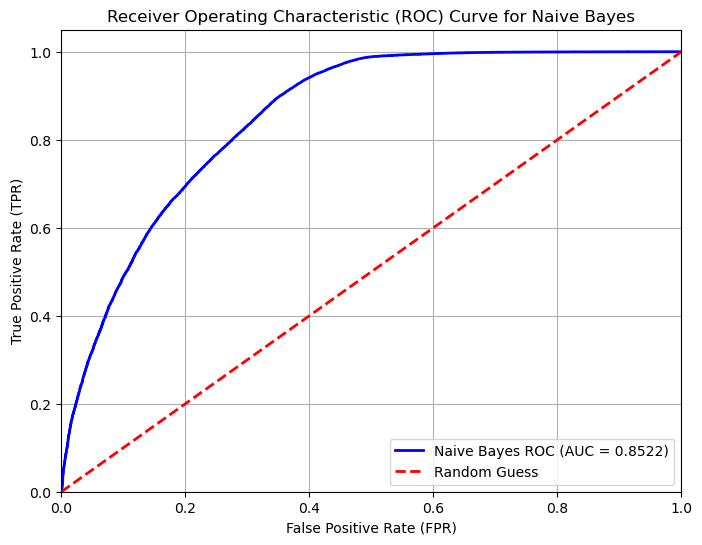

In [19]:
#朴素贝叶斯
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# 假设 X_train, y_train, X_valid, y_valid 已经加载和定义

print("\n----- 训练 Gaussian Naive Bayes 模型并记录性能指标 ----- ")

# 1. 初始化 Gaussian Naive Bayes 模型
nb_model = GaussianNB()

# 2. 训练模型
nb_model.fit(X_train, y_train)

# 3. 预测概率和标签
# 预测验证集上的概率 (需要第二列的概率，即正类的概率)
nb_proba_valid = nb_model.predict_proba(X_valid)[:, 1]
# 预测验证集上的标签
nb_pred = nb_model.predict(X_valid)

# 4. 计算准确率和AUC
nb_acc = accuracy_score(y_valid, nb_pred)
nb_auc = roc_auc_score(y_valid, nb_proba_valid)

print(f"Naive Bayes 模型验证集 AUC: {nb_auc:.4f}")
print(f"Naive Bayes 模型验证集准确率: {nb_acc:.4f}")

# 5. 绘制 ROC 曲线

print("\n----- 绘制 Naive Bayes ROC 曲线 ----- ")

# 计算 ROC 曲线的 FPR 和 TPR
fpr, tpr, thresholds = roc_curve(y_valid, nb_proba_valid)
roc_auc = auc(fpr, tpr)

# 绘制图形
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Naive Bayes ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess') # 绘制对角线

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve for Naive Bayes')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [2]:
try:
    !jupyter nbconvert --to python pre_payback.ipynb
    # python即转化为.py，script即转化为.html
    # filename替换为要转换的文件名
except:
    pass

[NbConvertApp] Converting notebook pre_payback.ipynb to python
[NbConvertApp] Writing 28859 bytes to pre_payback.py
